### Medicare Home Health Patient Experience | Healthcare Operations & Executive Analytics

---

## Project Overview

Healthcare organizations rely on patient experience and quality metrics to identify performance gaps, prioritize improvement initiatives, and support data-driven operational decision-making.

This project analyzes Medicare Home Health patient survey data to evaluate state-level quality performance and identify the operational factors most associated with patient satisfaction and agency performance.

The analysis combines exploratory data analysis, statistical relationships, machine learning, scenario analysis, and business intelligence to translate healthcare quality data into actionable insights for healthcare leaders.

### Business Questions

1. Which quality metrics are most strongly associated with overall patient satisfaction?
2. Which operational areas should healthcare organizations prioritize to improve quality ratings?
3. Can machine learning help identify important predictors of healthcare performance?
4. How can healthcare analytics support executive decision-making?

### Analytical Approach

**Data Review → Exploratory Analysis → Relationship Analysis → Predictive Modeling → Scenario Analysis → Executive Insights**

### Tools

**Python | Pandas | NumPy | Scikit-learn | Matplotlib | Tableau**

In [1]:
# Core libraries
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Project directory
project_dir = Path.cwd().parent

# Load Medicare Home Health patient survey data
data_path = project_dir / "data" / "Home Health Care Patient Survey State Data.xlsx"
df = pd.read_excel(data_path)

# Preview the dataset
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
display(df.head())

Dataset shape: 10 rows × 8 columns


,State Abbreviation,HHT Health Care Given in Professional Way,HHT Health Care Communicated Well With Patients,HHT Health Care Discussed Pain Medicines and Home Safety,Patients Who Gave 9 or 10 HHA Rating,Patients Reported Yes To Recommend HHA To Friends And Family,Number Of Completed Surveys,Response Rate
0,AK,88,86,83,86,82,615,20
1,AL,92,89,87,89,84,22714,27
2,AR,91,88,84,88,83,15319,27
3,AZ,88,84,78,84,76,17022,25
4,CA,87,84,82,82,76,97936,18


## 1. Data Review & Quality Assessment

Before conducting statistical or predictive analysis, the dataset is reviewed to confirm its structure, completeness, and suitability for analysis.

The dataset contains state-level Medicare Home Health patient experience measures covering professional care, communication, medication and home-safety discussions, overall patient ratings, recommendation rates, completed surveys, and survey response rates.

This section evaluates:

- Dataset dimensions and variable types
- Missing values
- Duplicate records
- Summary characteristics of the analytical variables

In [2]:
# Review dataset structure and data quality
print("DATASET OVERVIEW")
print("-" * 50)
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

print("\nDATA TYPES")
print("-" * 50)
print(df.dtypes)

print("\nMISSING VALUES")
print("-" * 50)
print(df.isnull().sum())

print("\nDUPLICATE RECORDS")
print("-" * 50)
print(f"Duplicate rows: {df.duplicated().sum()}")

DATASET OVERVIEW
--------------------------------------------------
Rows: 10
Columns: 8

DATA TYPES
--------------------------------------------------
State Abbreviation                                                str
HHT Health Care Given in Professional Way                       int64
HHT Health Care Communicated Well With Patients                 int64
HHT Health Care Discussed Pain Medicines and Home Safety        int64
Patients Who Gave 9 or 10 HHA Rating                            int64
Patients Reported Yes To Recommend HHA To Friends And Family    int64
Number Of Completed Surveys                                     int64
Response Rate                                                   int64
dtype: object

MISSING VALUES
--------------------------------------------------
State Abbreviation                                              0
HHT Health Care Given in Professional Way                       0
HHT Health Care Communicated Well With Patients                 0
HHT Health

In [3]:
# Select analytical variables
quality_metrics = [
    "HHT Health Care Given in Professional Way",
    "HHT Health Care Communicated Well With Patients",
    "HHT Health Care Discussed Pain Medicines and Home Safety",
    "Patients Who Gave 9 or 10 HHA Rating",
    "Patients Reported Yes To Recommend HHA To Friends And Family",
    "Number Of Completed Surveys",
    "Response Rate"
]

# Generate descriptive statistics
summary_stats = df[quality_metrics].describe().T

# Display key summary measures
summary_stats[["mean", "std", "min", "50%", "max"]].round(2)

,mean,std,min,50%,max
HHT Health Care Given in Professional Way,87.8,3.79,78.0,88.5,92.0
HHT Health Care Communicated Well With Patients,84.6,4.79,72.0,85.5,89.0
HHT Health Care Discussed Pain Medicines and Home Safety,81.1,3.60,74.0,81.5,87.0
Patients Who Gave 9 or 10 HHA Rating,84.2,4.16,74.0,85.0,89.0
Patients Reported Yes To Recommend HHA To Friends And Family,77.4,6.79,60.0,78.5,84.0
Number Of Completed Surveys,27046.6,35597.44,615.0,14418.0,97936.0
Response Rate,23.3,2.91,18.0,23.5,27.0


## 2. Exploratory Analysis

Exploratory analysis is used to evaluate relationships among patient experience and quality measures before predictive modeling is introduced.

Particular attention is given to overall patient rating and recommendation rate because these measures represent important indicators of patient experience and perceived healthcare quality.

In [4]:
# Calculate correlations among patient experience and quality measures
correlation_metrics = [
    "HHT Health Care Given in Professional Way",
    "HHT Health Care Communicated Well With Patients",
    "HHT Health Care Discussed Pain Medicines and Home Safety",
    "Patients Who Gave 9 or 10 HHA Rating",
    "Patients Reported Yes To Recommend HHA To Friends And Family"
]

correlation_matrix = df[correlation_metrics].corr()

correlation_matrix.round(3)

,HHT Health Care Given in Professional Way,HHT Health Care Communicated Well With Patients,HHT Health Care Discussed Pain Medicines and Home Safety,Patients Who Gave 9 or 10 HHA Rating,Patients Reported Yes To Recommend HHA To Friends And Family
HHT Health Care Given in Professional Way,1.000,0.980,0.822,0.982,0.970
HHT Health Care Communicated Well With Patients,0.980,1.000,0.859,0.964,0.980
HHT Health Care Discussed Pain Medicines and Home Safety,0.822,0.859,1.000,0.829,0.871
Patients Who Gave 9 or 10 HHA Rating,0.982,0.964,0.829,1.000,0.977
Patients Reported Yes To Recommend HHA To Friends And Family,0.970,0.980,0.871,0.977,1.000


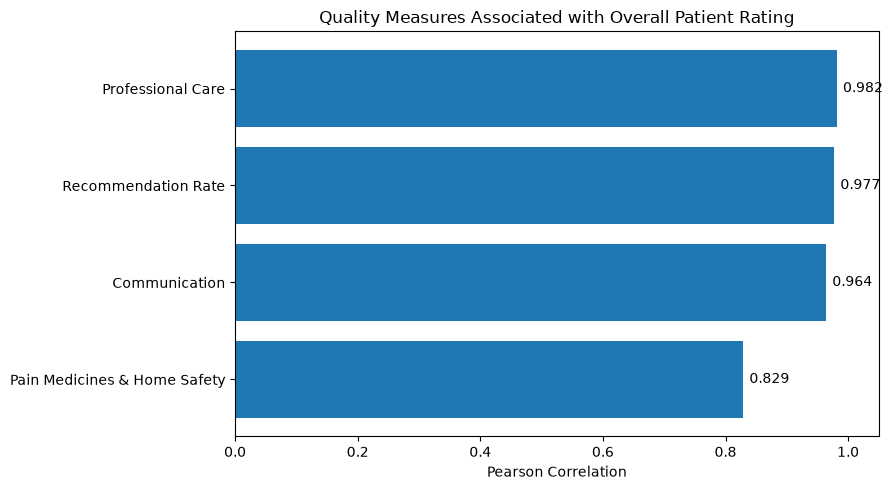

In [5]:
# Correlation of quality measures with overall patient rating
rating_target = "Patients Who Gave 9 or 10 HHA Rating"

rating_correlations = (
    correlation_matrix[rating_target]
    .drop(rating_target)
    .sort_values()
)

# Create readable labels for visualization
rating_labels = {
    "HHT Health Care Given in Professional Way": "Professional Care",
    "HHT Health Care Communicated Well With Patients": "Communication",
    "HHT Health Care Discussed Pain Medicines and Home Safety": "Pain Medicines & Home Safety",
    "Patients Reported Yes To Recommend HHA To Friends And Family": "Recommendation Rate"
}

rating_correlations.index = [
    rating_labels.get(label, label) for label in rating_correlations.index
]

# Plot correlations
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    rating_correlations.index,
    rating_correlations.values
)

ax.set_title("Quality Measures Associated with Overall Patient Rating")
ax.set_xlabel("Pearson Correlation")
ax.set_xlim(0, 1.05)

# Add correlation values
for bar in bars:
    value = bar.get_width()
    ax.text(
        value + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center"
    )

plt.tight_layout()
plt.show()

### Key Finding: Patient Satisfaction Drivers

Professional Care shows the strongest relationship with overall patient rating (**r = 0.982**), followed closely by Communication (**r = 0.964**) among the operational quality measures.

Recommendation Rate is also strongly associated with Patient Rating (**r = 0.977**). However, recommendation is treated as a patient experience outcome rather than an operational care process, so it is interpreted separately from Professional Care and Communication when evaluating potential improvement priorities.

Pain Medicines & Home Safety remains positively associated with Patient Rating (**r = 0.829**) but demonstrates a comparatively weaker relationship than Professional Care and Communication.

**Operational Interpretation:**  
The exploratory results suggest that how professionally care is delivered and how effectively providers communicate with patients may be particularly important areas for healthcare organizations evaluating patient experience performance.

> **Analytical Note:** These correlations identify associations, not causal relationships. Because the dataset contains only 10 state-level observations and several quality measures are highly correlated with one another, findings should be interpreted as exploratory signals rather than definitive evidence of causal impact.

## 3. Exploratory Predictive Modeling

A Random Forest regression model is used to explore which operational quality measures contribute most strongly to variation in overall patient rating.

The model uses the following predictors:

- Professional Care
- Communication
- Pain Medicines & Home Safety
- Completed Surveys
- Response Rate

**Target:** Overall Patient Rating

Recommendation Rate is intentionally excluded from the predictor set because it represents a related patient-experience outcome rather than an operational care process.

> **Modeling Limitation:** The dataset contains only 10 state-level observations. Therefore, the Random Forest model is used for exploratory feature-ranking purposes rather than as a validated production forecasting model. Feature importance results should be interpreted as directional signals and considered alongside the correlation analysis.

In [6]:
from sklearn.ensemble import RandomForestRegressor

# Define operational predictors and target
predictor_columns = [
    "HHT Health Care Given in Professional Way",
    "HHT Health Care Communicated Well With Patients",
    "HHT Health Care Discussed Pain Medicines and Home Safety",
    "Number Of Completed Surveys",
    "Response Rate"
]

target_column = "Patients Who Gave 9 or 10 HHA Rating"

X = df[predictor_columns]
y = df[target_column]

# Initialize and fit exploratory Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)

rf_model.fit(X, y)

# Extract feature importance
feature_importance = pd.DataFrame({
    "Feature": predictor_columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

# Create recruiter-friendly feature labels
feature_labels = {
    "HHT Health Care Given in Professional Way": "Professional Care",
    "HHT Health Care Communicated Well With Patients": "Communication",
    "HHT Health Care Discussed Pain Medicines and Home Safety": "Pain Medicines & Home Safety",
    "Number Of Completed Surveys": "Completed Surveys",
    "Response Rate": "Response Rate"
}

feature_importance["Feature"] = feature_importance["Feature"].map(feature_labels)

feature_importance.reset_index(drop=True)

,Feature,Importance
0,Communication,0.337060
1,Professional Care,0.257070
2,Pain Medicines & Home Safety,0.236463
3,Response Rate,0.096670
4,Completed Surveys,0.072738


In [7]:
# Evaluate feature-importance stability using leave-one-state-out analysis
stability_results = []

for i in range(len(df)):
    # Remove one state at a time
    X_subset = X.drop(index=df.index[i])
    y_subset = y.drop(index=df.index[i])

    # Fit the same Random Forest specification
    rf_subset = RandomForestRegressor(
        n_estimators=500,
        random_state=42
    )
    rf_subset.fit(X_subset, y_subset)

    # Store feature importance results
    state_result = {
        "State Removed": df.loc[df.index[i], "State Abbreviation"]
    }

    for feature, importance in zip(
        predictor_columns,
        rf_subset.feature_importances_
    ):
        state_result[feature_labels[feature]] = importance

    stability_results.append(state_result)

# Combine results
stability_df = pd.DataFrame(stability_results)

# Summarize average importance and variability
stability_summary = (
    stability_df
    .drop(columns="State Removed")
    .agg(["mean", "std"])
    .T
    .rename(columns={
        "mean": "Mean Importance",
        "std": "Std. Dev."
    })
    .sort_values("Mean Importance", ascending=False)
)

stability_summary.round(3)

,Mean Importance,Std. Dev.
Communication,0.312,0.036
Professional Care,0.262,0.012
Pain Medicines & Home Safety,0.230,0.028
Response Rate,0.110,0.031
Completed Surveys,0.085,0.028


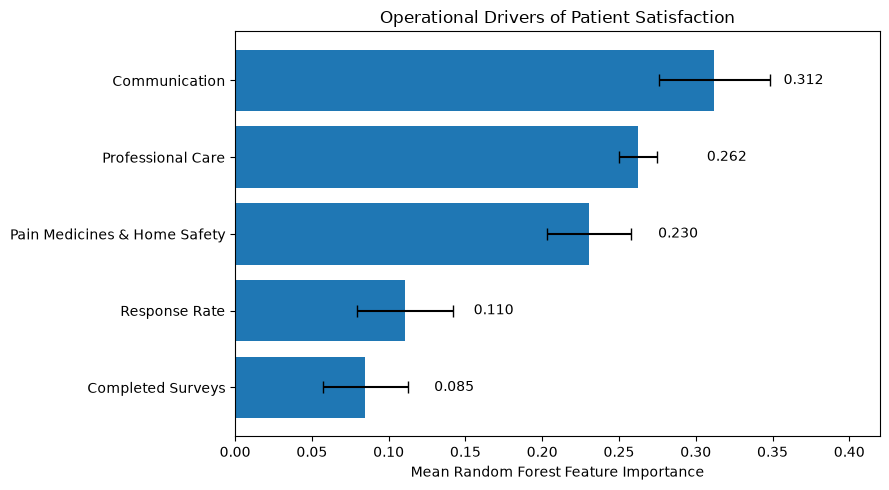

In [8]:
# Visualize average feature importance across leave-one-state-out iterations
plot_data = stability_summary.sort_values("Mean Importance")

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    plot_data.index,
    plot_data["Mean Importance"],
    xerr=plot_data["Std. Dev."],
    capsize=4
)

ax.set_title("Operational Drivers of Patient Satisfaction")
ax.set_xlabel("Mean Random Forest Feature Importance")
ax.set_ylabel("")

# Add mean importance values
for bar, value in zip(bars, plot_data["Mean Importance"]):
    ax.text(
        value + 0.045,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center")

ax.set_xlim(0, 0.42)

plt.tight_layout()
plt.show()

### Model Interpretation

The exploratory Random Forest model identifies **Communication** and **Professional Care** as the two leading operational features associated with overall patient rating.

This finding is directionally consistent with the correlation analysis. Professional Care showed the strongest direct correlation with Patient Rating (**r = 0.982**), while Communication also demonstrated a very strong relationship (**r = 0.964**).

A leave-one-state-out sensitivity analysis was performed to assess whether the Random Forest feature rankings changed substantially when individual states were removed. Across these iterations:

- **Communication** remained the highest-ranked feature on average (**mean importance = 0.312**).
- **Professional Care** remained the second-highest feature (**mean importance = 0.262**) and demonstrated relatively low variability across iterations (**SD = 0.012**).
- Pain Medicines & Home Safety remained a secondary operational signal.
- Response Rate and Completed Surveys consistently demonstrated lower feature importance.

**Executive Interpretation:**  
Across correlation analysis, exploratory machine learning, and sensitivity testing, **Communication and Professional Care consistently emerge as the strongest operational signals associated with patient satisfaction**. These findings suggest that patient-provider communication and professional care delivery may represent important areas for quality-improvement initiatives.

> **Analytical Limitation:** The dataset contains only 10 state-level observations. The sensitivity analysis evaluates the consistency of feature rankings within this dataset but does not establish external predictive validity or causal relationships. Results should therefore be interpreted as exploratory evidence supporting operational prioritization rather than definitive estimates of impact.

## 4. Operational Scenario Analysis

Exploratory scenario analysis is used to examine how predicted patient satisfaction changes when selected operational quality measures are adjusted within realistic values observed in the dataset.

Rather than attempting to identify a theoretical "optimal" combination of features, the analysis compares practical improvement scenarios focused on the operational areas identified most consistently in the exploratory and machine-learning analyses.

The scenarios are designed to support business interpretation and prioritization, not to estimate causal effects.

> **Analytical Note:** Scenario results are model-based estimates derived from a small state-level dataset. They illustrate directional differences within the fitted model and should not be interpreted as guaranteed outcomes from operational interventions.

In [9]:
# Define baseline and realistic operational improvement scenarios

# Use the average state profile as the baseline
baseline = X.mean().copy()

# Use observed 75th-percentile performance as realistic improvement targets
professional_target = df[
    "HHT Health Care Given in Professional Way"
].quantile(0.75)

communication_target = df[
    "HHT Health Care Communicated Well With Patients"
].quantile(0.75)

# Create scenario profiles
scenario_profiles = {
    "Baseline": baseline.copy(),
    "Improve Communication": baseline.copy(),
    "Improve Professional Care": baseline.copy(),
    "Improve Both": baseline.copy()
}

# Adjust only the operational measures being evaluated
scenario_profiles["Improve Communication"][
    "HHT Health Care Communicated Well With Patients"
] = communication_target

scenario_profiles["Improve Professional Care"][
    "HHT Health Care Given in Professional Way"
] = professional_target

scenario_profiles["Improve Both"][
    "HHT Health Care Communicated Well With Patients"
] = communication_target

scenario_profiles["Improve Both"][
    "HHT Health Care Given in Professional Way"
] = professional_target

# Display scenario assumptions
scenario_assumptions = pd.DataFrame({
    "Scenario": [
        "Baseline",
        "Improve Communication",
        "Improve Professional Care",
        "Improve Both"
    ],
    "Communication": [
        baseline["HHT Health Care Communicated Well With Patients"],
        communication_target,
        baseline["HHT Health Care Communicated Well With Patients"],
        communication_target
    ],
    "Professional Care": [
        baseline["HHT Health Care Given in Professional Way"],
        baseline["HHT Health Care Given in Professional Way"],
        professional_target,
        professional_target
    ]
})

scenario_assumptions.round(2)

,Scenario,Communication,Professional Care
0,Baseline,84.6,87.8
1,Improve Communication,87.5,87.8
2,Improve Professional Care,84.6,89.0
3,Improve Both,87.5,89.0


In [10]:
# Estimate patient satisfaction for each operational scenario

scenario_results = []

for scenario_name, profile in scenario_profiles.items():
    
    # Convert scenario profile to the format expected by the model
    scenario_df = pd.DataFrame(
        [profile],
        columns=predictor_columns
    )
    
    # Generate predicted patient rating
    predicted_rating = rf_model.predict(scenario_df)[0]
    
    scenario_results.append({
        "Scenario": scenario_name,
        "Predicted Patient Rating": predicted_rating
    })

# Create results table
scenario_results_df = pd.DataFrame(scenario_results)

# Calculate change relative to baseline
baseline_prediction = scenario_results_df.loc[
    scenario_results_df["Scenario"] == "Baseline",
    "Predicted Patient Rating"
].iloc[0]

scenario_results_df["Change vs. Baseline"] = (
    scenario_results_df["Predicted Patient Rating"] - baseline_prediction
)

scenario_results_df.round(2)

,Scenario,Predicted Patient Rating,Change vs. Baseline
0,Baseline,84.60,0.00
1,Improve Communication,85.30,0.70
2,Improve Professional Care,84.79,0.19
3,Improve Both,85.48,0.88


### Scenario Interpretation

Using the average state profile as the baseline, the exploratory model estimated an overall patient rating of **84.60%**.

When Communication was increased to the observed 75th-percentile benchmark while other measures remained constant, the predicted patient rating increased to **85.30%**, representing a modeled improvement of **0.70 percentage points**.

Improving Professional Care alone produced a smaller modeled increase of **0.19 percentage points**, while improving both Communication and Professional Care produced the largest estimated improvement, increasing predicted patient rating to **85.48%** (**+0.88 percentage points**).

**Executive Interpretation:**  
The scenario analysis reinforces Communication as a potentially high-value operational priority while suggesting that combined improvements in Communication and Professional Care may provide the strongest overall patient-experience opportunity. These findings complement the earlier correlation and feature-importance analyses and demonstrate how predictive analytics can support operational prioritization.

> **Important Limitation:** These scenarios are exploratory model estimates based on 10 state-level observations. They represent modeled associations within the available data and should not be interpreted as causal effects or guaranteed outcomes from operational changes.

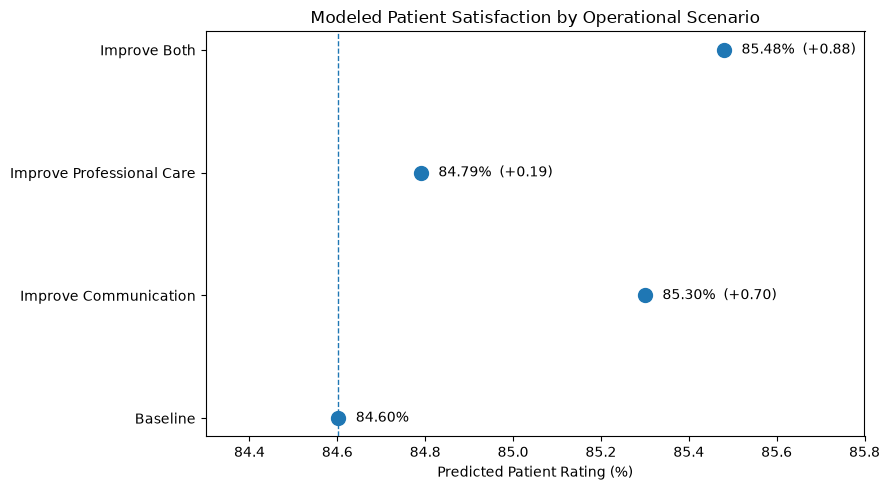

In [11]:
# Visualize modeled patient satisfaction across operational scenarios

plot_scenarios = scenario_results_df.copy()

fig, ax = plt.subplots(figsize=(9, 5))

# Plot scenario estimates as points
ax.scatter(
    plot_scenarios["Predicted Patient Rating"],
    plot_scenarios["Scenario"],
    s=100
)

# Add a baseline reference line
ax.axvline(
    baseline_prediction,
    linestyle="--",
    linewidth=1
)

# Add predicted rating and change vs. baseline labels
for _, row in plot_scenarios.iterrows():
    scenario = row["Scenario"]
    rating = row["Predicted Patient Rating"]
    change = row["Change vs. Baseline"]

    if scenario == "Baseline":
        label = f"{rating:.2f}%"
    else:
        label = f"{rating:.2f}%  (+{change:.2f})"

    ax.text(
        rating + 0.04,
        scenario,
        label,
        va="center"
    )

ax.set_title("Modeled Patient Satisfaction by Operational Scenario")
ax.set_xlabel("Predicted Patient Rating (%)")
ax.set_ylabel("")
ax.set_xlim(84.3, 85.8)

plt.tight_layout()
plt.show()

## 5. Executive Findings & Business Recommendations

The final section translates the analytical findings into operational priorities for healthcare leaders and connects the exploratory analysis, predictive modeling, and scenario analysis back to the project's original business questions.

### Business Question 1: Which quality metrics are most strongly associated with overall patient satisfaction?

The analysis consistently identified **Professional Care** and **Communication** as the strongest operational measures associated with overall patient satisfaction.

- **Professional Care** demonstrated the strongest direct relationship with Patient Rating (**r = 0.982**).
- **Communication** also demonstrated a very strong relationship with Patient Rating (**r = 0.964**).
- The exploratory Random Forest analysis ranked Communication and Professional Care as the two leading operational features.
- Leave-one-state-out sensitivity testing supported the consistency of this finding, with Communication averaging **0.312** feature importance and Professional Care averaging **0.262** across iterations.

**Executive Finding:**  
Patient perceptions of how professionally care is delivered and how effectively home health teams communicate with patients emerge as the most consistent operational signals associated with overall patient satisfaction in this dataset.

These results represent strong associations within the analyzed state-level data and should not be interpreted as evidence of causal relationships.

### Business Question 2: Which operational areas should healthcare organizations prioritize to improve quality ratings?

The combined analytical evidence suggests that **Communication should be a primary improvement priority, supported by continued focus on Professional Care**.

Although Professional Care demonstrated the strongest direct correlation with Patient Rating, Communication ranked highest in the exploratory Random Forest analysis and produced the largest individual improvement in the operational scenario analysis.

When Communication was increased from the average state-level value (**84.6%**) to the observed 75th-percentile benchmark (**87.5%**), the model estimated Patient Rating increasing from **84.60% to 85.30%**, a modeled improvement of **0.70 percentage points**.

Improving Professional Care alone produced a smaller modeled increase of **0.19 percentage points**, while improving both Communication and Professional Care produced the strongest scenario result at **85.48%**, representing a modeled increase of **0.88 percentage points** over baseline.

**Executive Recommendation:**  
Healthcare leaders should consider prioritizing initiatives that strengthen patient communication while maintaining high standards of professional care delivery. Potential operational focus areas may include clearer patient education, consistent care-plan communication, responsiveness to patient questions, and reinforcement of patient-centered communication practices among care teams.

Because the scenario analysis is based on a small observational state-level dataset, these recommendations should be treated as **data-informed areas for further evaluation and quality-improvement planning**, rather than guaranteed causal interventions.

### Business Question 3: Can machine learning identify important operational features associated with healthcare performance?

The exploratory Random Forest model provided an additional method for evaluating which operational measures were most important for explaining variation in Patient Rating within the analyzed dataset

The initial model ranked **Communication** and **Professional Care** as the two leading features associated with Patient Rating. A leave-one-state-out sensitivity analysis was then used to evaluate whether these feature rankings remained reasonably consistent when individual states were removed from the analysis.

Across the sensitivity iterations:

- **Communication** ranked highest on average with a mean feature importance of **0.312**.
- **Professional Care** ranked second with a mean importance of **0.262** and showed particularly low variability (**SD = 0.012**).
- **Pain Medicines & Home Safety** remained a secondary operational feature with a mean importance of **0.230**.
- **Response Rate** and **Completed Surveys** demonstrated substantially lower average feature importance.

These machine-learning findings were directionally consistent with the relationship analysis, which independently identified Communication and Professional Care as strongly associated with Patient Rating.

**Executive Finding:**  
Machine learning can help identify and prioritize operational signals within healthcare quality data, particularly when its results are interpreted alongside descriptive and statistical analysis. In this project, multiple analytical approaches consistently highlighted **Communication and Professional Care** as important dimensions of patient experience.

> **Modeling Limitation:** With only 10 state-level observations, this Random Forest model should be considered exploratory rather than a validated predictive model. Its primary value in this project is demonstrating feature prioritization, sensitivity analysis, and responsible interpretation—not establishing production-ready predictive performance.

### Business Question 4: How can analytics support executive decision-making?

Healthcare analytics can transform patient-experience measures into operational information that leaders can use to monitor performance, identify improvement opportunities, and prioritize quality initiatives.

In this project, multiple analytical methods support different levels of decision-making:

- **Descriptive analytics** establish performance benchmarks and reveal variation across quality measures.
- **Correlation analysis** identifies operational measures strongly associated with patient satisfaction.
- **Exploratory machine learning** provides an additional method for prioritizing potential performance drivers.
- **Sensitivity and scenario analysis** help evaluate how modeled performance changes under realistic operational improvement scenarios.
- **Business intelligence visualization** translates analytical findings into an interactive executive view for monitoring state-level performance.

The accompanying **Tableau Executive Dashboard** extends the analysis by allowing healthcare leaders to compare Patient Satisfaction, Recommendation Rate, and Professional Care across states while monitoring key performance indicators including average Patient Rating, average Recommendation Rate, and completed survey volume.

**Executive Takeaway:**  
Analytics is most valuable when it moves beyond reporting individual metrics and helps leadership determine **where performance differs, which operational areas deserve attention, and where quality-improvement efforts may warrant further investigation**.

For this analysis, Communication and Professional Care consistently emerged as important operational signals, while the Tableau dashboard provides the executive monitoring layer needed to place those findings within broader state-level performance.

## 6. Limitations

The findings in this project should be interpreted within the scope and structure of the available data.

- **Small sample size:** The analysis contains only 10 state-level observations. This substantially limits the ability to validate predictive performance or generalize machine-learning results beyond the analyzed dataset.
- **State-level aggregation:** The dataset represents aggregated state performance rather than individual patients or individual home health agencies. Relationships observed at the state level should not be assumed to represent patient-level or agency-level effects.
- **Observational analysis:** Correlation, feature importance, and scenario results identify statistical and model-based relationships but do not establish causation.
- **Highly correlated quality measures:** Several patient-experience measures are strongly related to one another, making it difficult to isolate the independent contribution of individual operational factors.
- **Exploratory machine learning:** The Random Forest model is used primarily for feature prioritization and scenario exploration. It has not been externally validated and should not be considered a production forecasting model.
- **Scenario assumptions:** Operational scenarios use observed 75th-percentile values as realistic improvement benchmarks. Predicted changes represent model-based estimates rather than guaranteed outcomes from healthcare interventions.

These limitations reinforce the importance of combining machine learning with descriptive analysis, statistical relationships, operational context, and transparent interpretation when using healthcare data to support decision-making.

## 7. Conclusion

This project demonstrates how healthcare quality data can be transformed into actionable operational insights through a combination of exploratory analysis, machine learning, scenario modeling, and business intelligence.

Across multiple analytical approaches, **Communication and Professional Care consistently emerged as the strongest operational signals associated with overall patient satisfaction**. Professional Care demonstrated the strongest direct correlation with Patient Rating, while Communication ranked highest in average feature importance in the exploratory Random Forest analysis and produced the largest individual modeled improvement in the operational scenario analysis.

The scenario analysis further suggested that improving both Communication and Professional Care to observed high-performance benchmarks produced the strongest modeled patient-satisfaction result. These findings highlight potential areas for healthcare leaders to investigate when developing patient-experience and quality-improvement initiatives.

The accompanying Tableau Executive Dashboard extends the analysis into an interactive decision-support environment, allowing state-level performance, recommendation rates, professional care measures, and key performance indicators to be monitored together.

### Final Takeaway

Healthcare analytics provides the greatest value when technical analysis is translated into clear operational priorities. In this project, descriptive analytics, statistical relationships, exploratory machine learning, scenario analysis, and executive visualization work together to identify potential quality-improvement opportunities while maintaining appropriate caution around the limitations of a small observational dataset.

**Communication and Professional Care emerge as the primary operational areas warranting further evaluation for patient-experience improvement.**